In [15]:
#Loading necessary libraries
import os
import numpy as np
import pandas as pd
from pathlib import Path
import json
from datetime import datetime
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
#Reproducibility settings and constants
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32

In [5]:

#Checking data directory
RAW_DIR = Path("../data/raw/asl_alphabet")

print("TensorFlow:", tf.__version__)
print("RAW_DIR exists:", RAW_DIR.exists())

TensorFlow: 2.20.0
RAW_DIR exists: True


In [7]:
#Recreate splits + datasets

classes = sorted([p.name for p in RAW_DIR.iterdir() if p.is_dir()])
label_to_id = {c:i for i, c in enumerate(classes)}
id_to_label = {i:c for c, i in label_to_id.items()}

rows = []
for c in classes:
    folder = RAW_DIR / c
    for img_name in os.listdir(folder):
        img_path = folder / img_name
        if img_path.is_file():
            rows.append({"path": str(img_path), "label": c, "label_id": label_to_id[c]})

meta_df = pd.DataFrame(rows)

train_df, temp_df = train_test_split(
    meta_df, test_size=0.30, stratify=meta_df["label_id"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label_id"], random_state=SEED
)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))


Train: 99582 Val: 21339 Test: 21340


In [8]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=1)         # grayscale
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32) / 255.0              # normalize 0-1
    return img, label

def make_dataset(df, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((df["path"].values, df["label_id"].values))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(2000, seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, shuffle=True)
val_ds   = make_dataset(val_df, shuffle=False)
test_ds  = make_dataset(test_df, shuffle=False)

num_classes = len(classes)
print("Classes:", num_classes)


Classes: 36


In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(64, 64, 1)),
    
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36)             │         4,644 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687,268 (2.62 MB)

 Trainable params: 687,268 (2.62 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"])


In [11]:
history = model.fit(train_ds, validation_data=val_ds,epochs=5)


Epoch 1/5
3112/3112 ━━━━━━━━━━━━━━━━━━━━ 361s 115ms/step - accuracy: 0.8878 - loss: 0.3820 - val_accuracy: 0.9871 - val_loss: 0.0470
Epoch 2/5
3112/3112 ━━━━━━━━━━━━━━━━━━━━ 354s 112ms/step - accuracy: 0.9860 - loss: 0.0453 - val_accuracy: 0.9875 - val_loss: 0.0379
Epoch 3/5
3112/3112 ━━━━━━━━━━━━━━━━━━━━ 375s 119ms/step - accuracy: 0.9930 - loss: 0.0242 - val_accuracy: 0.9899 - val_loss: 0.0299
Epoch 4/5
3112/3112 ━━━━━━━━━━━━━━━━━━━━ 378s 120ms/step - accuracy: 0.9945 - loss: 0.0195 - val_accuracy: 0.9965 - val_loss: 0.0118
Epoch 5/5
3112/3112 ━━━━━━━━━━━━━━━━━━━━ 392s 125ms/step - accuracy: 0.9959 - loss: 0.0155 - val_accuracy: 0.9961 - val_loss: 0.0189


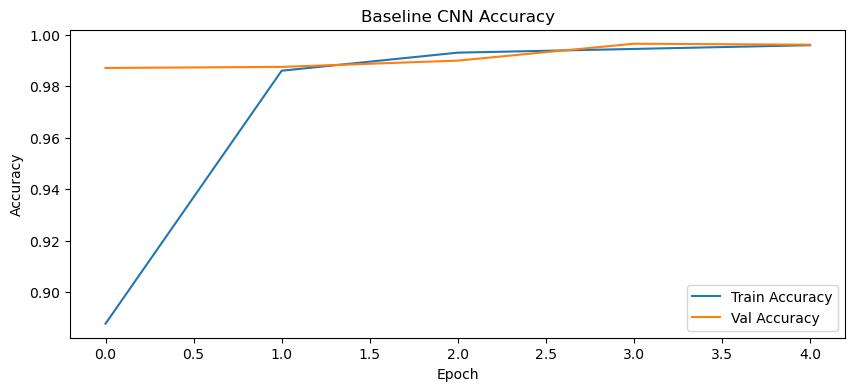

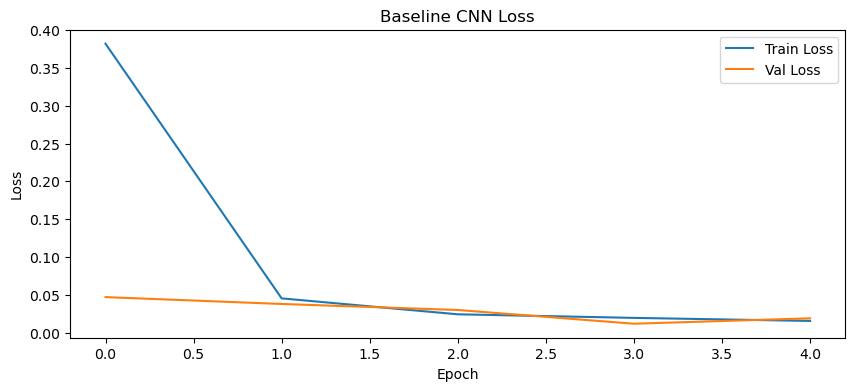

In [12]:
plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [13]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

667/667 ━━━━━━━━━━━━━━━━━━━━ 55s 82ms/step - accuracy: 0.9959 - loss: 0.0231
Test Accuracy: 0.9958763122558594
Test Loss: 0.02312943898141384


In [ ]:
from pathlib import Path
import json
from datetime import datetime

In [16]:
#Saving Model
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / "baseline_cnn.keras"
model.save(model_path)

print("Saved model to:", model_path)

Saved model to: ..\models\baseline_cnn.keras


In [17]:
#Saving class mapping
ARTIFACTS_DIR = Path("../artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

#Save in a stable order
class_mapping = {
    "classes": classes,         
    "label_to_id": label_to_id, 
    "id_to_label": id_to_label, }

with open(ARTIFACTS_DIR / "class_mapping.json", "w") as f:
    json.dump(class_mapping, f, indent=2)

print(" Saved class mapping to artifacts/class_mapping.json")

 Saved class mapping to artifacts/class_mapping.json


In [18]:
#Saving training history
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
metrics_path = ARTIFACTS_DIR / f"train_history_{run_id}.csv"

history_df = pd.DataFrame(history.history)
history_df["epoch"] = range(1, len(history_df) + 1)
history_df["model_version"] = "baseline_cnn"
history_df["run_id"] = run_id

history_df.to_csv(metrics_path, index=False)
print("Saved training history to:", metrics_path)
history_df.tail()

Saved training history to: ..\artifacts\train_history_20260205_225054.csv


,accuracy,loss,val_accuracy,val_loss,epoch,model_version,run_id
0,0.887751,0.382049,0.987066,0.046970,1,baseline_cnn,20260205_225054
1,0.986001,0.045306,0.987488,0.037900,2,baseline_cnn,20260205_225054
2,0.993021,0.024233,0.989925,0.029934,3,baseline_cnn,20260205_225054
3,0.994457,0.019502,0.996485,0.011779,4,baseline_cnn,20260205_225054
4,0.995913,0.015469,0.996110,0.018936,5,baseline_cnn,20260205_225054


In [19]:
#Saving model card
model_card = {
    "model_version": "baseline_cnn",
    "image_size": list(IMAGE_SIZE),
    "batch_size": BATCH_SIZE,
    "num_classes": num_classes,
    "optimizer": "Adam(1e-3)",
    "loss": "SparseCategoricalCrossentropy",
    "notes": "Baseline CNN trained on standardized 64x64 grayscale images with stratified splits."
}

with open(ARTIFACTS_DIR / f"model_card_{run_id}.json", "w") as f:
    json.dump(model_card, f, indent=2)

print("Saved model card to:", ARTIFACTS_DIR / f"model_card_{run_id}.json")


Saved model card to: ..\artifacts\model_card_20260205_225054.json
